# **CNN Image Classification with Transfer Learning**

**Dataset:** Images of 75 butterfly species

**Objective:** Identify

# **1. Import Libraries**

In [1]:
!pip install -q tensorflow matplotlib scikit-learn seaborn pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

import seaborn as sns
from sklearn.metrics import confusion_matrix

matches = glob.glob('/content/drive/MyDrive/**/00. Dataset img', recursive=True)
if matches:
    DATASET_DIR = matches[0]
    print(f'Dataset found: {DATASET_DIR}')
else:
    DATASET_DIR = '/content/drive/MyDrive/00. Dataset img'
    print(f'Using default path: {DATASET_DIR}')

print('\nContents of dataset folder:')
for item in sorted(os.listdir(DATASET_DIR)):
    print(f'  - {item}')

Dataset found: /content/drive/MyDrive/Colab Notebooks/Day 38: Project - CNN RNN DNN LSTM/02. CNN/00. Dataset img

Contents of dataset folder:
  - Testing_set.csv
  - Training_set.csv
  - test
  - train


In [4]:
# ── Find and load CSV file
csv_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.csv')]
print(f'CSV files found: {csv_files}')


csv_name = None
for name in ['Training_set.csv', 'training_set.csv', 'train.csv',
             'Training.csv', 'labels.csv']:
    if name in csv_files:
        csv_name = name
        break

if csv_name is None and csv_files:
    csv_name = csv_files[0]

CSV_PATH = os.path.join(DATASET_DIR, csv_name)
df = pd.read_csv(CSV_PATH)

print(f'\n Label Dataset: {csv_name}')
print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nColumns: {df.columns.tolist()}')

CSV files found: ['Training_set.csv', 'Testing_set.csv']

 Label Dataset: Training_set.csv
Shape: (6499, 2)

First 5 rows:
      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART

Columns: ['filename', 'label']


# **2. Dataset Overview**

In [5]:
cols = df.columns.tolist()

filename_col = None
label_col = None

for col in cols:
    if col.lower() in ['filename', 'file', 'image', 'filepath', 'file_name']:
        filename_col = col
    if col.lower() in ['label', 'class', 'category', 'species', 'target']:
        label_col = col

if filename_col is None:
    filename_col = cols[0]
if label_col is None:
    label_col = cols[1]

print(f'Filename column : {filename_col}')
print(f'Label column    : {label_col}')

possible_img_dirs = ['train', 'Train', 'images', 'Images', 'data', 'Data']
IMAGE_DIR = None
for d in possible_img_dirs:
    candidate = os.path.join(DATASET_DIR, d)
    if os.path.isdir(candidate):
        IMAGE_DIR = candidate
        break

if IMAGE_DIR is None:
    IMAGE_DIR = DATASET_DIR

print(f'\nImage directory: {IMAGE_DIR}')

classes = sorted(df[label_col].unique().tolist())
NUM_CLASSES = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(f'\nFound {NUM_CLASSES} butterfly species:')
for cls in classes:
    count = len(df[df[label_col] == cls])
    print(f'   [{cls}] → {count} images')

Filename column : filename
Label column    : label

Image directory: /content/drive/MyDrive/Colab Notebooks/Day 38: Project - CNN RNN DNN LSTM/02. CNN/00. Dataset img/train

Found 75 butterfly species:
   [ADONIS] → 88 images
   [AFRICAN GIANT SWALLOWTAIL] → 75 images
   [AMERICAN SNOOT] → 74 images
   [AN 88] → 85 images
   [APPOLLO] → 90 images
   [ATALA] → 100 images
   [BANDED ORANGE HELICONIAN] → 97 images
   [BANDED PEACOCK] → 83 images
   [BECKERS WHITE] → 81 images
   [BLACK HAIRSTREAK] → 85 images
   [BLUE MORPHO] → 75 images
   [BLUE SPOTTED CROW] → 86 images
   [BROWN SIPROETA] → 99 images
   [CABBAGE WHITE] → 90 images
   [CAIRNS BIRDWING] → 83 images
   [CHECQUERED SKIPPER] → 95 images
   [CHESTNUT] → 85 images
   [CLEOPATRA] → 93 images
   [CLODIUS PARNASSIAN] → 87 images
   [CLOUDED SULPHUR] → 92 images
   [COMMON BANDED AWL] → 87 images
   [COMMON WOOD-NYMPH] → 90 images
   [COPPER TAIL] → 94 images
   [CRECENT] → 97 images
   [CRIMSON PATCH] → 72 images
   [DANAID EGGF

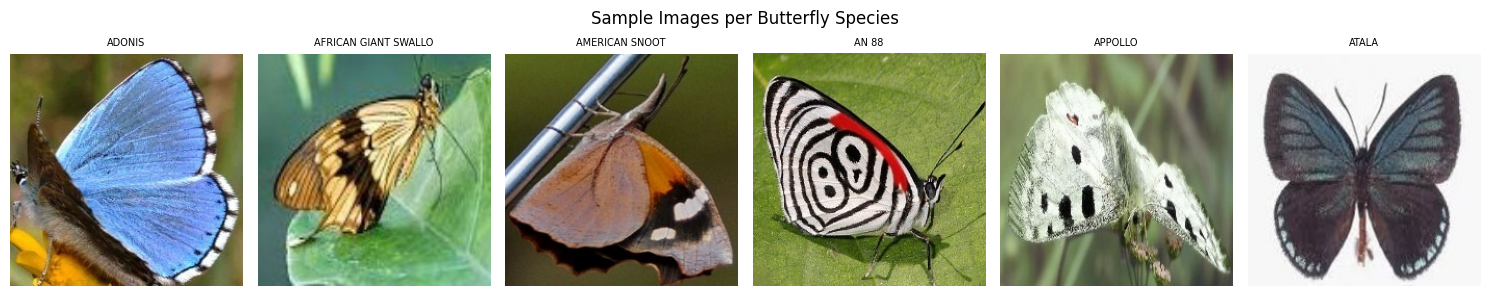

In [6]:
show_n = min(NUM_CLASSES, 6)
fig, axes = plt.subplots(1, show_n, figsize=(15, 3))
if show_n == 1:
    axes = [axes]

for ax, cls in zip(axes, classes[:show_n]):
    sample_file = df[df[label_col] == cls][filename_col].sample(1).values[0]
    img_path = os.path.join(IMAGE_DIR, sample_file)

    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(cls[:20], fontsize=7)
    else:
        ax.text(0.5, 0.5, 'Not found', ha='center', va='center')
        ax.set_title(cls[:20], fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Images per Butterfly Species', fontsize=12)
plt.tight_layout()
plt.show()

# **3. Data Preprocessing & Augmentation**

In [8]:
IMG_SIZE         = (128, 128)
BATCH_SIZE       = 16
EPOCHS           = 20
FINE_TUNE_EPOCHS = 10
VAL_SPLIT        = 0.2
SEED             = 42

In [9]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

df['filepath'] = df[filename_col].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)
df['label_idx'] = df[label_col].map(class_to_idx)
df['label_str'] = df[label_col]

df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)
print(f'Valid images found: {len(df)}')

train_df, val_df = train_test_split(
    df,
    test_size=VAL_SPLIT,
    stratify=df['label_str'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Training samples  : {len(train_df)}')
print(f'Validation samples: {len(val_df)}')

Valid images found: 6499
Training samples  : 5199
Validation samples: 1300


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=False
)

print(f'\nClass mapping (first 5):')
for k, v in list(train_generator.class_indices.items())[:5]:
    print(f'  {v}: {k}')

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.

Class mapping (first 5):
  0: ADONIS
  1: AFRICAN GIANT SWALLOWTAIL
  2: AMERICAN SNOOT
  3: AN 88
  4: APPOLLO


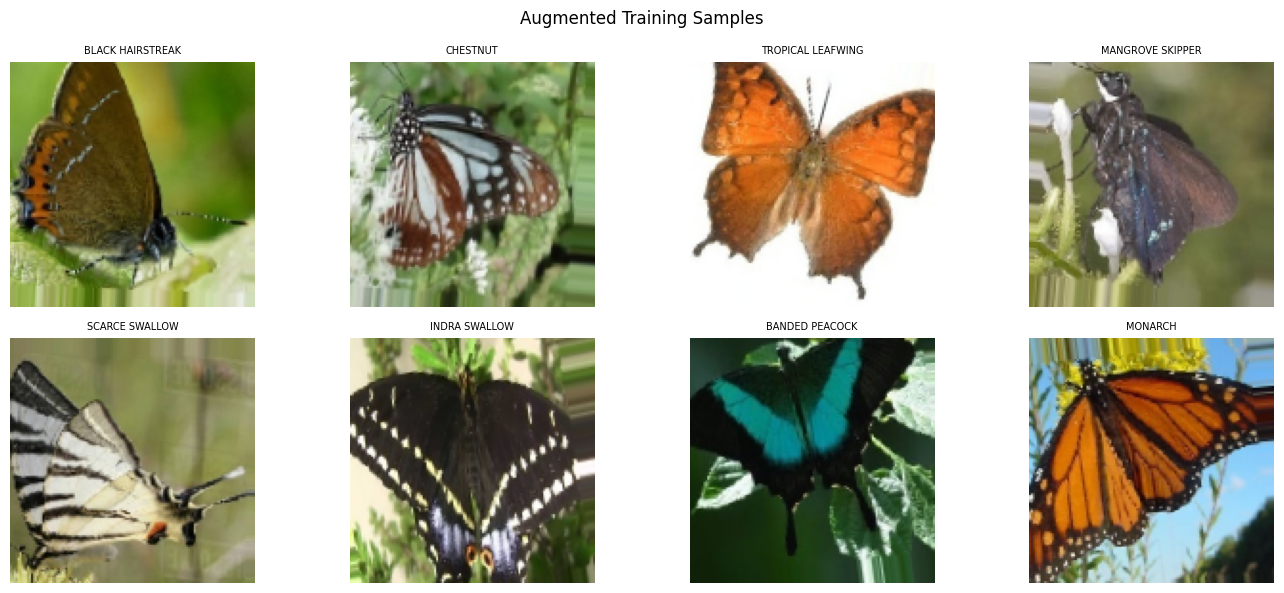

In [12]:
batch_imgs, batch_labels = next(train_generator)
idx_to_cls = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i < len(batch_imgs):
        ax.imshow(batch_imgs[i])
        label_idx = batch_labels[i].argmax()
        ax.set_title(idx_to_cls[label_idx][:20], fontsize=7)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

# **4. CNN Architecture Design**

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model
from tensorflow.keras.regularizers import l2

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

print(f'MobileNetV2 loaded — {len(base_model.layers)} layers (frozen)')
print(f'Backbone output shape: {base_model.output_shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded — 154 layers (frozen)
Backbone output shape: (None, 4, 4, 1280)


In [15]:
x = base_model.output
x = layers.GlobalAveragePooling2D(name='gap')(x)
print(f'After GlobalAveragePooling2D — shape: {x.shape}')

After GlobalAveragePooling2D — shape: (None, 1280)


In [16]:
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=l2(1e-4), name='fc1')(x)
x = layers.BatchNormalization(name='bn1')(x)
x = layers.Dropout(0.4, name='drop1')(x)

x = layers.Dense(128, activation='relu',
                 kernel_regularizer=l2(1e-4), name='fc2')(x)
x = layers.BatchNormalization(name='bn2')(x)
x = layers.Dropout(0.3, name='drop2')(x)


outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = Model(inputs=base_model.input, outputs=outputs,
              name='CNN_Butterfly_MobileNetV2')

print(f'Output classes : {NUM_CLASSES}')
print(f'Total params   : {model.count_params():,}')

Output classes : 75
Total params   : 2,630,027


In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Loss      : categorical_crossentropy')
print('Optimizer : Adam (lr=1e-3)')
model.summary(line_length=80)

Loss      : categorical_crossentropy
Optimizer : Adam (lr=1e-3)


Model: "CNN_Butterfly_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 64, 64,    │         864 │ input_layer[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 64, 64,    │         128 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 64, 64,    │           0 │ bn_Conv1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 64, 64,    │         288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 64, 64,    │         128 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 64, 64,    │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 64, 64,    │         512 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 64, 64,    │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 64, 64,    │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 64, 64,    │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 64, 64,    │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 65, 65,    │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 32, 32,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 32, 32,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 32, 32,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 2,630,027 (10.03 MB)

 Trainable params: 371,275 (1.42 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [18]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('Callbacks ready:')
print('  - EarlyStopping (patience=5)')
print('  - ReduceLROnPlateau (factor=0.5, patience=3)')
print('  - ModelCheckpoint → best_model_phase1.keras')

Callbacks ready:
  - EarlyStopping (patience=5)
  - ReduceLROnPlateau (factor=0.5, patience=3)
  - ModelCheckpoint → best_model_phase1.keras


# **5. Training Configuration & Execution**

In [19]:
history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1679 - loss: 3.8280
Epoch 1: val_accuracy improved from None to 0.63923, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 1524s 5s/step - accuracy: 0.3031 - loss: 3.0183 - val_accuracy: 0.6392 - val_loss: 1.4947 - learning_rate: 0.0010
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5661 - loss: 1.7667
Epoch 2: val_accuracy improved from 0.63923 to 0.75846, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 133s 409ms/step - accuracy: 0.5801 - loss: 1.6682 - val_accuracy: 0.7585 - val_loss: 1.0403 - learning_rate: 0.0010
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6629 - loss: 1.3231
Epoch 3: val_accuracy improved from 0.75846 to 0.78462, saving model to best_model_phase1.keras

Epoch 3: finished saving model to best_model_ph

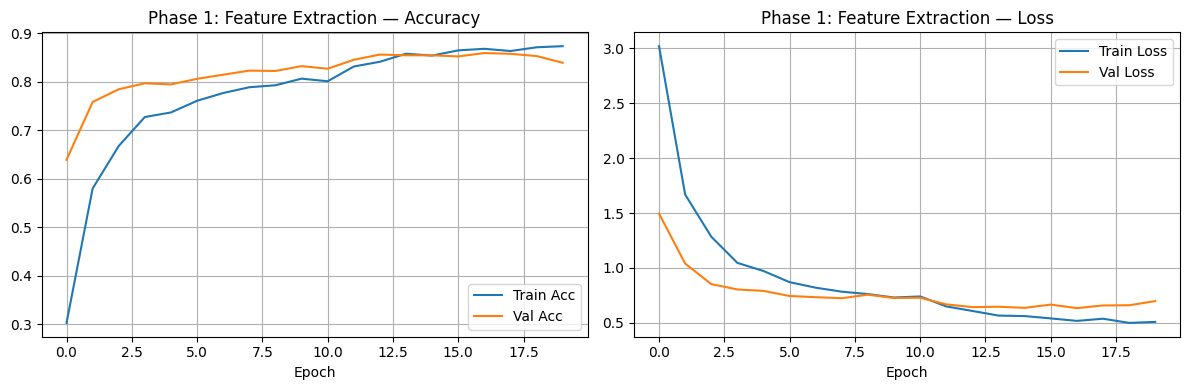

In [20]:
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1: Feature Extraction')

Fine-tuning: 30 backbone layers unfrozen

Starting Fine-Tuning Phase 2...

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7174 - loss: 1.0945
Epoch 1: val_accuracy improved from None to 0.79154, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 197s 550ms/step - accuracy: 0.7415 - loss: 0.9757 - val_accuracy: 0.7915 - val_loss: 0.9005 - learning_rate: 1.0000e-04
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8128 - loss: 0.7218
Epoch 2: val_accuracy improved from 0.79154 to 0.82154, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 173s 533ms/step - accuracy: 0.8159 - loss: 0.7087 - val_accuracy: 0.8215 - val_loss: 0.7748 - learning_rate: 1.0000e-04
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8521 - loss: 0.5845
Epoch 3: val_accuracy improved from 0.82154 to 0.84846, 

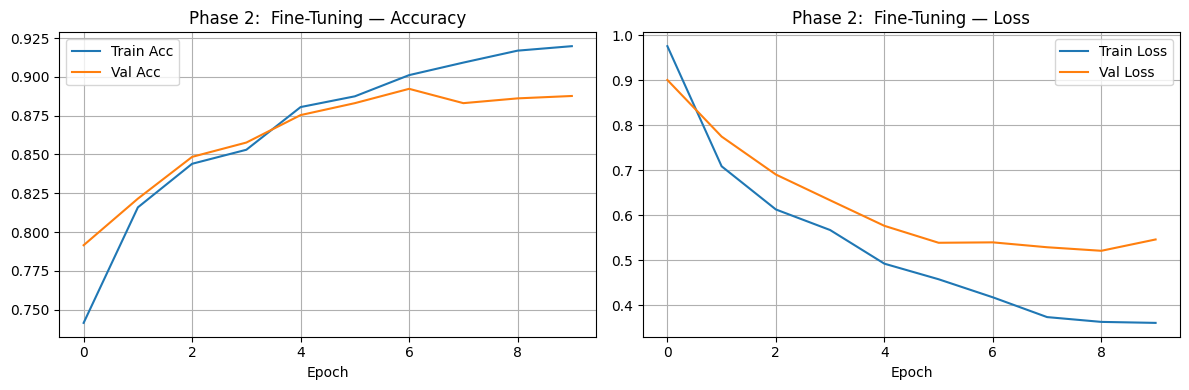

In [21]:
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning: {trainable_count} backbone layers unfrozen')

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_phase2.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('\nStarting Fine-Tuning Phase 2...\n')
history_phase2 = model.fit(
    train_generator,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

plot_history(history_phase2, 'Phase 2:  Fine-Tuning')

In [22]:
def build_model(dropout_rate=0.4, learning_rate=1e-3):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(dropout_rate * 0.75)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs=base.input, outputs=out)
    m.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

hp_configs = [
    {'lr': 1e-3, 'dropout': 0.3},
    {'lr': 1e-3, 'dropout': 0.5},
    {'lr': 5e-4, 'dropout': 0.4},
]

hp_results = []
HP_EPOCHS = 5
early_stop_hp = EarlyStopping(monitor='val_loss', patience=3,
                              restore_best_weights=True)

for cfg in hp_configs:
    print(f"Testing: lr={cfg['lr']}, dropout={cfg['dropout']}")
    m = build_model(dropout_rate=cfg['dropout'], learning_rate=cfg['lr'])
    h = m.fit(train_generator, epochs=HP_EPOCHS,
              validation_data=val_generator,
              callbacks=[early_stop_hp], verbose=0)
    best_val_acc  = max(h.history['val_accuracy'])
    best_val_loss = min(h.history['val_loss'])
    hp_results.append({
        'learning_rate': cfg['lr'],
        'dropout': cfg['dropout'],
        'best_val_acc': round(best_val_acc, 4),
        'best_val_loss': round(best_val_loss, 4)
    })
    print(f"  → val_accuracy={best_val_acc:.4f}")
    del m

hp_df = pd.DataFrame(hp_results).sort_values('best_val_acc', ascending=False)
print('\nHyperparameter Tuning Results:')
print(hp_df.to_string(index=False))

Testing: lr=0.001, dropout=0.3
  → val_accuracy=0.8054
Testing: lr=0.001, dropout=0.5
  → val_accuracy=0.7400
Testing: lr=0.0005, dropout=0.4
  → val_accuracy=0.7546

Hyperparameter Tuning Results:
 learning_rate  dropout  best_val_acc  best_val_loss
        0.0010      0.3        0.8054         0.7603
        0.0005      0.4        0.7546         1.0195
        0.0010      0.5        0.7400         0.9510


# **6. Model Evaluation**

In [23]:
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

val_generator.reset()
print('Running predictions on validation set...')
y_pred_proba = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_generator.classes

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted')

print(f'\nAccuracy : {acc:.4f}')
print(f'F1-Score : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

Running predictions on validation set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step

Accuracy : 0.8862
F1-Score : 0.8838

Classification Report:
                           precision    recall  f1-score   support

                   ADONIS       0.90      1.00      0.95        18
AFRICAN GIANT SWALLOWTAIL       0.88      0.93      0.90        15
           AMERICAN SNOOT       0.88      1.00      0.94        15
                    AN 88       1.00      1.00      1.00        17
                  APPOLLO       0.94      0.83      0.88        18
                    ATALA       1.00      0.95      0.97        20
 BANDED ORANGE HELICONIAN       1.00      0.90      0.95        20
           BANDED PEACOCK       1.00      0.88      0.94        17
            BECKERS WHITE       0.65      0.94      0.77        16
         BLACK HAIRSTREAK       1.00      0.71      0.83        17
              BLUE MORPHO       1.00      0.87      0.93        15
        BLUE SPOTTED CROW       0.85      1.00     

Per-Class Accuracy Summary:
Species                              Correct    Total   Accuracy
-----------------------------------------------------------------
ADONIS                                    18       18    100.0%
AMERICAN SNOOT                            15       15    100.0%
AN 88                                     17       17    100.0%
GREY HAIRSTREAK                           17       17    100.0%
MANGROVE SKIPPER                          17       17    100.0%
COMMON WOOD-NYMPH                         18       18    100.0%
CRIMSON PATCH                             14       14    100.0%
CHESTNUT                                  17       17    100.0%
CLEOPATRA                                 19       19    100.0%
CABBAGE WHITE                             18       18    100.0%
BLUE SPOTTED CROW                         17       17    100.0%
TROPICAL LEAFWING                         17       17    100.0%
ZEBRA LONG WING                           15       15    100.0%
STRAITED 

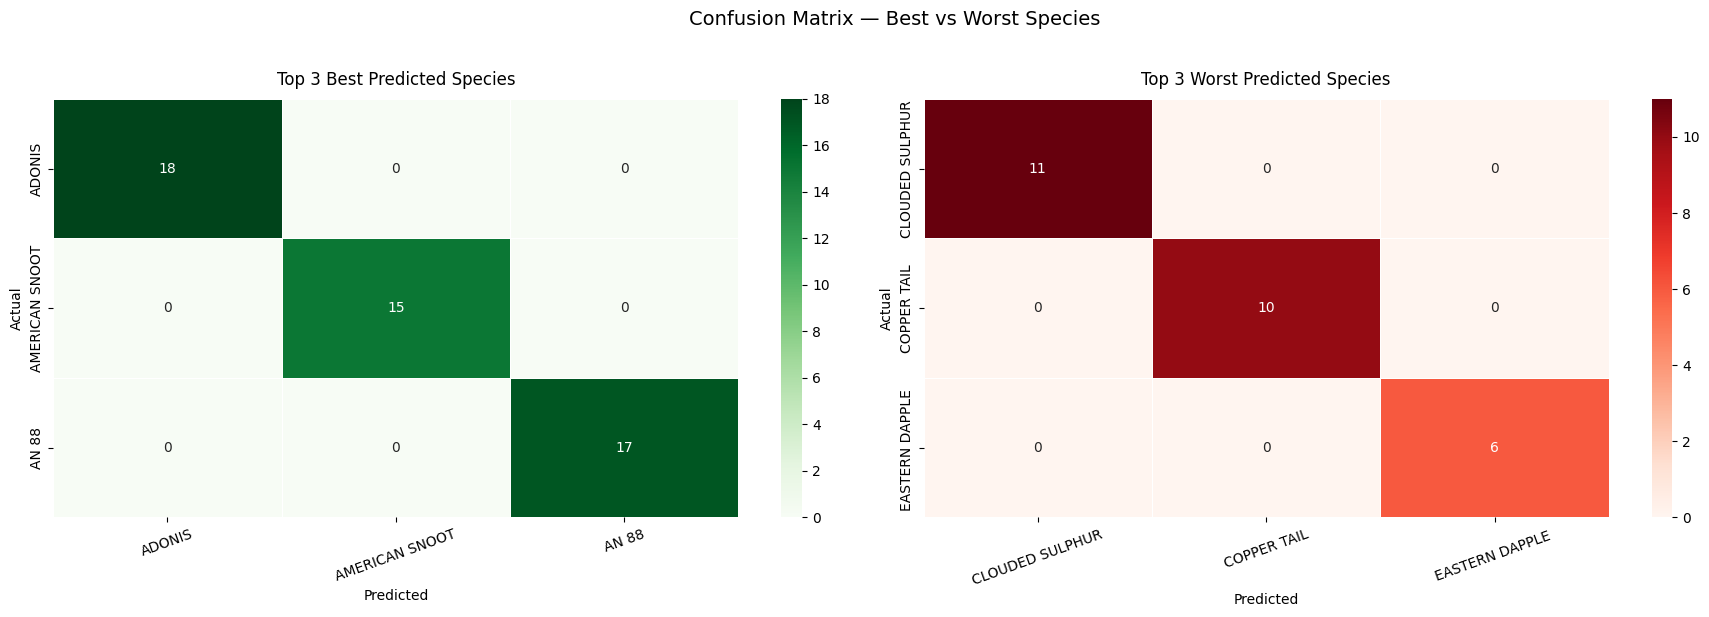

<Figure size 640x480 with 0 Axes>

In [32]:
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

class_acc_df = pd.DataFrame({
    'species': classes,
    'correct': cm.diagonal(),
    'total': cm.sum(axis=1),
    'accuracy': per_class_acc
}).sort_values('accuracy', ascending=False)

print("Per-Class Accuracy Summary:")
print(f"{'Species':<35} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 65)
for _, row in class_acc_df.iterrows():
    print(f"{row['species']:<35} {int(row['correct']):>8} {int(row['total']):>8} {row['accuracy']:>9.1%}")

top3 = class_acc_df.head(3)['species'].tolist()
bot3 = class_acc_df.tail(3)['species'].tolist()
selected = top3 + bot3

print(f"\nTop 3 Best  : {top3}")
print(f"Top 3 Worst : {bot3}")

selected_indices = [classes.index(c) for c in selected]

cm_sub = cm[np.ix_(selected_indices, selected_indices)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_idx = [classes.index(c) for c in top3]
cm_top = cm[np.ix_(top_idx, top_idx)]
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Greens',
            xticklabels=[c[:15] for c in top3],
            yticklabels=[c[:15] for c in top3],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Top 3 Best Predicted Species', fontsize=12, pad=10)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=20)

bot_idx = [classes.index(c) for c in bot3]
cm_bot = cm[np.ix_(bot_idx, bot_idx)]
sns.heatmap(cm_bot, annot=True, fmt='d', cmap='Reds',
            xticklabels=[c[:15] for c in bot3],
            yticklabels=[c[:15] for c in bot3],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Top 3 Worst Predicted Species', fontsize=12, pad=10)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrix — Best vs Worst Species', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

for bar, acc in zip(bars, class_acc_df['accuracy']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.0%}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

# **7. Export Keras Model**

In [25]:
import json, shutil

MODEL_PATH = 'cnn_classification_model.keras'
model.save(MODEL_PATH)
print(f'Model saved: {MODEL_PATH}')

label_map = {str(idx): cls for idx, cls in idx_to_class.items()}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print(f'Label map saved: label_map.json')
print(f'Labels: {label_map}')

SAVE_DIR = '/content/drive/MyDrive/CNN_Model_Output'
os.makedirs(SAVE_DIR, exist_ok=True)
shutil.copy(MODEL_PATH, os.path.join(SAVE_DIR, MODEL_PATH))
shutil.copy('label_map.json', os.path.join(SAVE_DIR, 'label_map.json'))
print(f'\nFiles saved to Google Drive: {SAVE_DIR}')

Model saved: cnn_classification_model.keras
Label map saved: label_map.json
Labels: {'0': 'ADONIS', '1': 'AFRICAN GIANT SWALLOWTAIL', '2': 'AMERICAN SNOOT', '3': 'AN 88', '4': 'APPOLLO', '5': 'ATALA', '6': 'BANDED ORANGE HELICONIAN', '7': 'BANDED PEACOCK', '8': 'BECKERS WHITE', '9': 'BLACK HAIRSTREAK', '10': 'BLUE MORPHO', '11': 'BLUE SPOTTED CROW', '12': 'BROWN SIPROETA', '13': 'CABBAGE WHITE', '14': 'CAIRNS BIRDWING', '15': 'CHECQUERED SKIPPER', '16': 'CHESTNUT', '17': 'CLEOPATRA', '18': 'CLODIUS PARNASSIAN', '19': 'CLOUDED SULPHUR', '20': 'COMMON BANDED AWL', '21': 'COMMON WOOD-NYMPH', '22': 'COPPER TAIL', '23': 'CRECENT', '24': 'CRIMSON PATCH', '25': 'DANAID EGGFLY', '26': 'EASTERN COMA', '27': 'EASTERN DAPPLE WHITE', '28': 'EASTERN PINE ELFIN', '29': 'ELBOWED PIERROT', '30': 'GOLD BANDED', '31': 'GREAT EGGFLY', '32': 'GREAT JAY', '33': 'GREEN CELLED CATTLEHEART', '34': 'GREY HAIRSTREAK', '35': 'INDRA SWALLOW', '36': 'IPHICLUS SISTER', '37': 'JULIA', '38': 'LARGE MARBLE', '39': 'MA

In [33]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model(MODEL_PATH)

with open('label_map.json') as f:
    loaded_label_map = json.load(f)
print(f'Label map: {loaded_label_map}')

val_generator.reset()
sample_batch, _ = next(val_generator)
sample_batch = sample_batch[:4]

pred_original = model.predict(sample_batch, verbose=0)
pred_loaded   = loaded_model.predict(sample_batch, verbose=0)
max_diff = np.max(np.abs(pred_original - pred_loaded))

print(f'\nConsistency check (max diff): {max_diff:.2e}')
if max_diff < 1e-5:
    print('Original and loaded model outputs are identical')
else:
    print('Small floating point difference')

Label map: {'0': 'ADONIS', '1': 'AFRICAN GIANT SWALLOWTAIL', '2': 'AMERICAN SNOOT', '3': 'AN 88', '4': 'APPOLLO', '5': 'ATALA', '6': 'BANDED ORANGE HELICONIAN', '7': 'BANDED PEACOCK', '8': 'BECKERS WHITE', '9': 'BLACK HAIRSTREAK', '10': 'BLUE MORPHO', '11': 'BLUE SPOTTED CROW', '12': 'BROWN SIPROETA', '13': 'CABBAGE WHITE', '14': 'CAIRNS BIRDWING', '15': 'CHECQUERED SKIPPER', '16': 'CHESTNUT', '17': 'CLEOPATRA', '18': 'CLODIUS PARNASSIAN', '19': 'CLOUDED SULPHUR', '20': 'COMMON BANDED AWL', '21': 'COMMON WOOD-NYMPH', '22': 'COPPER TAIL', '23': 'CRECENT', '24': 'CRIMSON PATCH', '25': 'DANAID EGGFLY', '26': 'EASTERN COMA', '27': 'EASTERN DAPPLE WHITE', '28': 'EASTERN PINE ELFIN', '29': 'ELBOWED PIERROT', '30': 'GOLD BANDED', '31': 'GREAT EGGFLY', '32': 'GREAT JAY', '33': 'GREEN CELLED CATTLEHEART', '34': 'GREY HAIRSTREAK', '35': 'INDRA SWALLOW', '36': 'IPHICLUS SISTER', '37': 'JULIA', '38': 'LARGE MARBLE', '39': 'MALACHITE', '40': 'MANGROVE SKIPPER', '41': 'MESTRA', '42': 'METALMARK', '4


Consistency check (max diff): 0.00e+00
Original and loaded model outputs are identical


In [27]:
# ── Export to TFLite (for Flutter app)
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

TFLITE_PATH = 'model_quantized.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f'TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)')
shutil.copy(TFLITE_PATH, os.path.join(SAVE_DIR, TFLITE_PATH))
print(f'TFLite model saved to Google Drive')

Saved artifact at '/tmp/tmpt6jx6xme'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 75), dtype=tf.float32, name=None)
Captures:
  135617843170000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843171344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843169616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843170384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843171920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843169040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843171536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843171728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843169808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617843172880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13561784317230

Image      : Image_1082.jpg
True label : VICEROY
Predicted  : VICEROY
Confidence : 72.97%


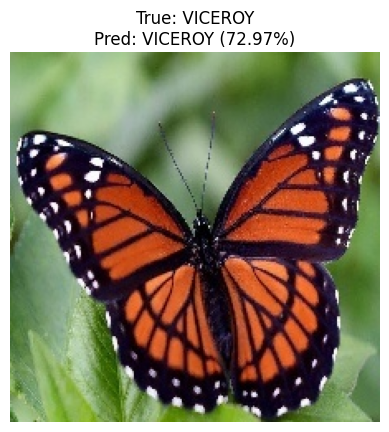

In [28]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model=loaded_model,
                  label_map=loaded_label_map):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    proba = model.predict(img_array, verbose=0)[0]
    pred_idx = int(np.argmax(proba))
    confidence = float(proba[pred_idx])

    return {
        'class': label_map[str(pred_idx)],
        'confidence': f'{confidence:.2%}',
        'probabilities': {
            label_map[str(i)]: f'{float(p):.2%}'
            for i, p in enumerate(proba)
        }
    }

# Test on a random validation image
sample_img_path = val_df['filepath'].sample(1).values[0]
result = predict_image(sample_img_path)
true_label = val_df[val_df['filepath'] == sample_img_path][label_col].values[0]

print(f'Image      : {os.path.basename(sample_img_path)}')
print(f'True label : {true_label}')
print(f'Predicted  : {result["class"]}')
print(f'Confidence : {result["confidence"]}')

# Show image
img_show = mpimg.imread(sample_img_path)
plt.imshow(img_show)
plt.title(f'True: {true_label}\nPred: {result["class"]} ({result["confidence"]})')
plt.axis('off')
plt.show()